# Actividad Individual 2. 
## Alumno: Tomas Moretti

## Dataset: Car Price Prediction and Vehicle Specifications
**Fuente:** Kaggle
**Dataset:** *Car Price Prediction and Vehicle Specifications*
**Autor:** iHasan88
**Enlace:** https://www.kaggle.com/datasets/ihasan88/car-price-prediction-and-vehicle-specifications

### Descripción

El conjunto de datos contiene información relacionada con **vehículos, sus características y sus precios**.
Las variables permiten analizar diferentes especificaciones de los automóviles y estudiar su posible relación con el precio de venta.

Se realizara un EDA básico del dataset:
estadística descriptiva
tipos de variables
relación entre variables
incluir al menos 3 gráficos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

df = pd.read_csv("carpricedataset.csv")

df.head()

,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
0,1,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,2,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60
2,3,BMW,2008,2.2,Diesel,Manual,74672,3,2,333,41894.40
3,4,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381,54046.70
4,5,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290,38010.35


Para conocer de que trata el dataset observamos una porcion de los primeros 5 registros para visualizar todas las columnas del dataframe. Podemos observar el ID del auto, la marca, el año, tamaño de motor, tipo de combustible, tipo de transmision, odometro, cantidad de puertas, cantidad de dueños, cantidad de potencia y el precio.

A continuacion veo los tipos de datos de cada variable y si poseen valores nulos.

In [3]:
df.dtypes

Car_ID            int64
Brand               str
Model_Year        int64
Engine_Size     float64
Fuel_Type           str
Transmission        str
Mileage           int64
Doors             int64
Owner_Count       int64
Horsepower        int64
Price           float64
dtype: object

Ahora observo si hay valores nulos

In [4]:
df.isnull().sum()

Car_ID          0
Brand           0
Model_Year      0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Horsepower      0
Price           0
dtype: int64

In [5]:
df.describe()

,Car_ID,Model_Year,Engine_Size,Mileage,Doors,Owner_Count,Horsepower,Price
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,2013.963000,2.967550,100736.956500,2.988000,2.532500,235.70950,46169.507675
std,577.494589,5.508248,1.146926,56002.915221,0.818041,1.125423,95.59811,9211.685713
min,1.000000,2005.000000,1.000000,5036.000000,2.000000,1.000000,70.00000,18911.550000
25%,500.750000,2009.000000,2.000000,52365.500000,2.000000,2.000000,154.00000,39764.000000
50%,1000.500000,2014.000000,2.900000,100590.500000,3.000000,3.000000,236.00000,46112.350000
75%,1500.250000,2019.000000,4.000000,148024.500000,4.000000,4.000000,319.00000,52471.387500
max,2000.000000,2023.000000,5.000000,199904.000000,4.000000,4.000000,399.00000,72267.800000


Podemos observar que:
Cantidad de filas:2000 (ademas no se encontraron valores nulos en ninguna columna)
la media del año de los vehiculos es aproximadamente 2014 al igual que la moda que es justo 2014. POr lo que la mayoria de los vehiculos rondan ese año de fabricación.
El millaje promedio del odometro es de 100736 millas y la mediana esta en 100590millas. Pero el mínimo es 5036 millas y el máximo 199904 millas, por lo que se ve a priori lo que pareceria una gran dispersión. Incluso los Q1,Q2,Q3 estan bastante proporcionales.
El promedio del precio de venta es de 46169 USD, y la mediana ronda los 46112 USD. 


## Frecuencia de variables categóricas

In [6]:
df["Brand"].value_counts()

Brand
Toyota     352
Hyundai    337
Tesla      330
Honda      329
Ford       326
BMW        326
Name: count, dtype: int64

In [7]:
df["Fuel_Type"].value_counts()

Fuel_Type
Diesel      537
Petrol      511
Electric    484
Hybrid      468
Name: count, dtype: int64

In [8]:
df["Transmission"].value_counts()

Transmission
Automatic    1018
Manual        982
Name: count, dtype: int64

la frecuencia de todas las variables categóricas estan a simple vista muy similares.

### Relación entre variables numericas
Quiero observar si hay relacion entre el año y precio como si existe relación entre año y millaje.
Como son variables numericas hago un grafico de scatterplot y luego calculo correlacion con Pearson.

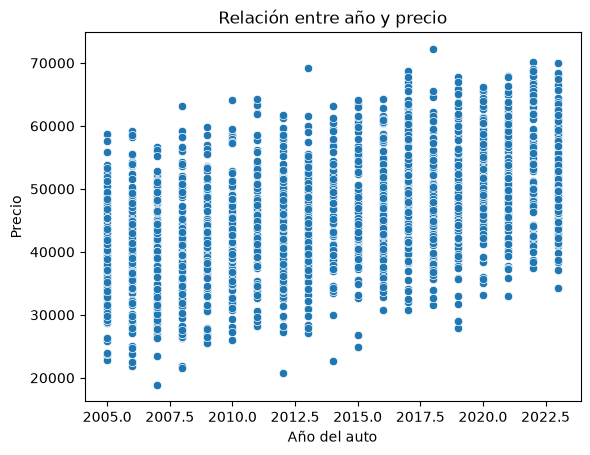

In [9]:
sns.scatterplot(data=df, x="Model_Year", y="Price")

plt.title("Relación entre año y precio")
plt.xlabel("Año del auto")
plt.ylabel("Precio")
plt.show()

Correlación entre año y precio

In [10]:
df["Model_Year"].corr(df["Price"])

np.float64(0.4686656946881676)

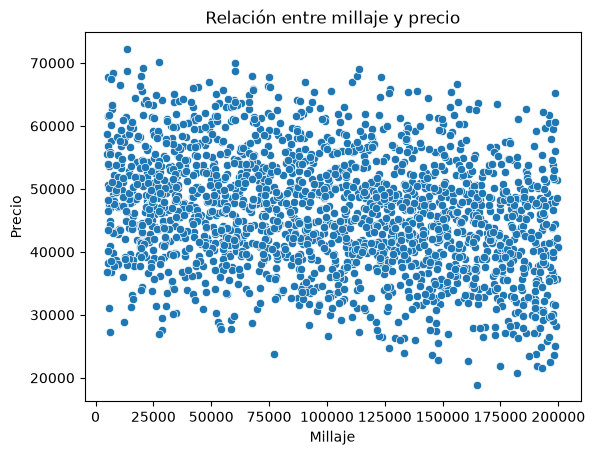

In [11]:
sns.scatterplot(data=df, x="Mileage", y="Price")

plt.title("Relación entre millaje y precio")
plt.xlabel("Millaje")
plt.ylabel("Precio")
plt.show()

In [12]:
df["Mileage"].corr(df["Price"])

np.float64(-0.266514381062666)

En los graficos puedo observar levemente que a medida que el kilometraje aumenta el precio disminuye.
Analogamente con el año y el precio, mas nuevo mayor precio. 
Pero es solo una intuicion porque los valores de correlacion no me dan suficiente cercanos a 1 (valor abs) como para indicar una correlacion lineal. 
Analizo respecto a marca y precio.

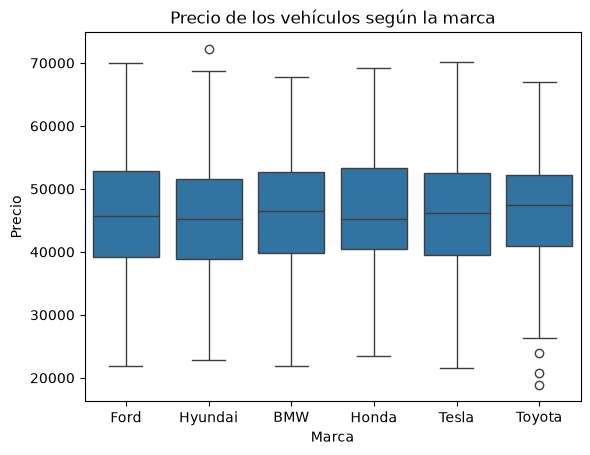

In [13]:
sns.boxplot(data=df, x="Brand", y="Price")

plt.title("Precio de los vehículos según la marca")
plt.xlabel("Marca")
plt.ylabel("Precio")
plt.show()

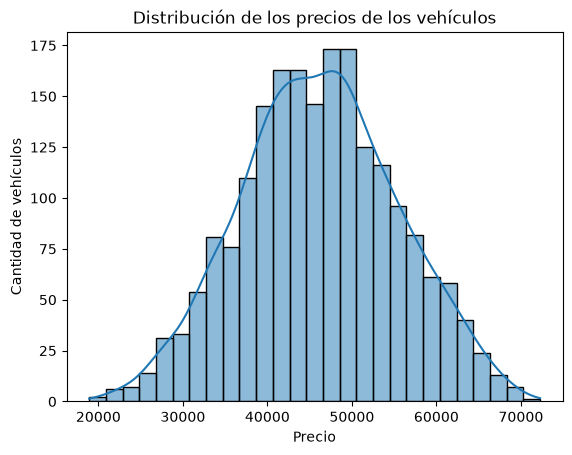

In [14]:
sns.histplot(data=df, x="Price", kde=True)

plt.title("Distribución de los precios de los vehículos")
plt.xlabel("Precio")
plt.ylabel("Cantidad de vehículos")
plt.show()

In [15]:
asimetria = df["Price"].skew()
curtosis = df["Price"].kurt()


print("Media:", df["Price"].mean())
print("Mediana:", df["Price"].median())
print("Desvío estándar:", df["Price"].std())
print("Asimetría:", df["Price"].skew())
print("Curtosis:", df["Price"].kurt())

Media: 46169.50767499999
Mediana: 46112.35
Desvío estándar: 9211.685713420957
Asimetría: 0.018929463908141726
Curtosis: -0.3323649752296842


Presenta una asimetría cercana a 0.
Ademas en el boxplot no observamos a priori y a simple vista una gran diferencia en los precios segun la marca. A priori, ya que siempre en esta primera etapa analicé todos los datos en general, no separe por año de auto, por ejemplo.

    